In [48]:
# from google.colab import drive
# drive.mount('/content/drive')

# Prediction Oil Temperature with ETTh1 dataset

### Import

In [49]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import math
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

### Read dataset

In [50]:
# Đọc dữ liệu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
df = pd.read_csv("ETTh1.csv")

df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

target_col = 'OT'

data = df.values

### MSE Loss

In [51]:
def mse_loss(y_pred,y_true):
    return np.mean((y_pred-y_true)**2)

### Information

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17420 entries, 2016-07-01 00:00:00 to 2018-06-26 19:00:00
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HUFL    17420 non-null  float64
 1   HULL    17420 non-null  float64
 2   MUFL    17420 non-null  float64
 3   MULL    17420 non-null  float64
 4   LUFL    17420 non-null  float64
 5   LULL    17420 non-null  float64
 6   OT      17420 non-null  float64
dtypes: float64(7)
memory usage: 1.1 MB


In [53]:
df.head()

,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
date,,,,,,,
2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


### Thông số

In [54]:
n = len(df)

train_size = int(n * 0.6)
val_size   = int(n * 0.2)
test_size = int(n * 0.2)
print(f'Train size:{train_size}')
lr = 1e-4
weight_decay = 1e-4
drop_out = 0.3

seq_len = 168
pred_len = 24
target_idx = 4

hidden_size = 128
num_layer = 2
epochs = 50

Train size:10452


### Histogram biến mục tiêu

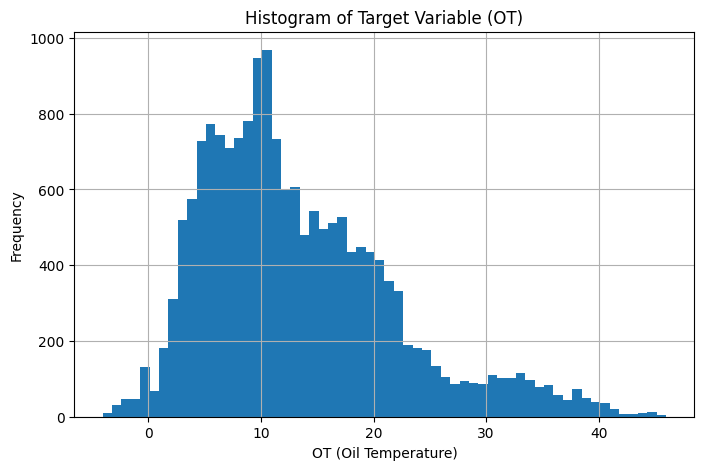

In [55]:
plt.figure(figsize=(8,5))
plt.hist(df["OT"], bins=60)
plt.title("Histogram of Target Variable (OT)")
plt.xlabel("OT (Oil Temperature)")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

### Biểu đồ tương quan

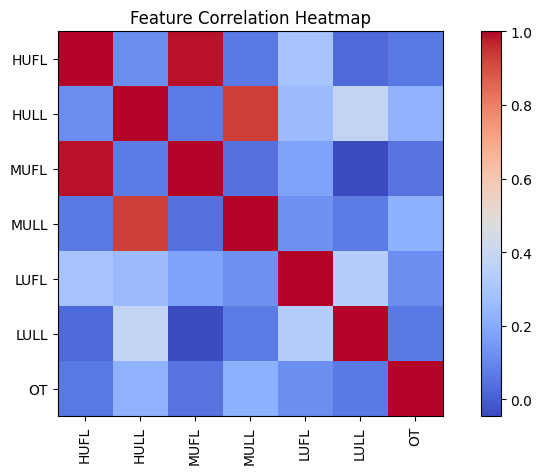

In [56]:
correlation = df.corr()
plt.figure(figsize=(10,5))
plt.imshow(correlation,cmap = 'coolwarm')
plt.colorbar()
plt.xticks(range(len(df.columns.tolist())), df.columns.tolist(), rotation=90)
plt.yticks(range(len(df.columns.tolist())), df.columns.tolist())

plt.title("Feature Correlation Heatmap")
plt.show()

In [57]:
# Drop cột MUFL MULL
df.drop(labels=['MUFL','MULL'],axis=1,inplace=True)

In [58]:
df.iloc[120:]

,HUFL,HULL,LUFL,LULL,OT
date,,,,,
2016-07-06 00:00:00,10.382,5.090,3.015,1.828,28.913000
2016-07-06 01:00:00,10.717,5.425,2.833,1.919,30.389999
2016-07-06 02:00:00,10.851,5.358,2.833,1.858,31.514999
2016-07-06 03:00:00,9.779,5.157,3.168,2.132,31.233999
2016-07-06 04:00:00,9.377,4.488,3.015,2.041,30.531000
...,...,...,...,...,...
2018-06-26 15:00:00,-1.674,3.550,3.472,1.523,10.904000
2018-06-26 16:00:00,-5.492,4.287,3.533,1.675,11.044000
2018-06-26 17:00:00,2.813,3.818,3.716,1.523,10.271000


### Data augment

In [59]:
stl = STL(df["OT"], period=24)
res = stl.fit()

trend = res.trend
seasonal = res.seasonal
residual = res.resid

df["trend"] = trend
df["seasonal"] = seasonal
df["residual"] = residual



In [60]:
df.head()

,HUFL,HULL,LUFL,LULL,OT,trend,seasonal,residual
date,,,,,,,,
2016-07-01 00:00:00,5.827,2.009,4.203,1.340,30.531000,20.656502,7.584735,2.289763
2016-07-01 01:00:00,5.693,2.076,4.142,1.371,27.787001,20.645468,4.554440,2.587092
2016-07-01 02:00:00,5.157,1.741,3.777,1.218,27.787001,20.634575,4.245313,2.907112
2016-07-01 03:00:00,5.090,1.942,3.807,1.279,25.044001,20.623845,2.788363,1.631792
2016-07-01 04:00:00,5.358,1.942,3.868,1.279,21.948000,20.613263,0.953354,0.381383


### Signal plot

plt.figure(figsize=(12,8))

plt.subplot(4,1,1)
plt.plot(df["OT"])
plt.title("Original")

plt.subplot(4,1,2)
plt.plot(trend)
plt.title("Trend")

plt.subplot(4,1,3)
plt.plot(seasonal)
plt.title("Seasonal")

plt.subplot(4,1,4)
plt.plot(residual)
plt.title("Residual")

plt.tight_layout()
plt.show()

In [61]:
train_df = df.iloc[:train_size]
val_df   = df.iloc[train_size:train_size+val_size]
test_df  = df.iloc[train_size+val_size:]

In [62]:
train_df.head()

,HUFL,HULL,LUFL,LULL,OT,trend,seasonal,residual
date,,,,,,,,
2016-07-01 00:00:00,5.827,2.009,4.203,1.340,30.531000,20.656502,7.584735,2.289763
2016-07-01 01:00:00,5.693,2.076,4.142,1.371,27.787001,20.645468,4.554440,2.587092
2016-07-01 02:00:00,5.157,1.741,3.777,1.218,27.787001,20.634575,4.245313,2.907112
2016-07-01 03:00:00,5.090,1.942,3.807,1.279,25.044001,20.623845,2.788363,1.631792
2016-07-01 04:00:00,5.358,1.942,3.868,1.279,21.948000,20.613263,0.953354,0.381383


### Timer Frezee

In [63]:
train_df[6554:6576].head(30)

,HUFL,HULL,LUFL,LULL,OT,trend,seasonal,residual
date,,,,,,,,
2017-03-31 02:00:00,10.248,0.0,4.264,1.279,6.753,5.903357,0.703572,0.146071
2017-03-31 03:00:00,10.248,0.0,4.264,1.279,6.753,5.933898,0.464941,0.354161
2017-03-31 04:00:00,10.248,0.0,4.264,1.279,6.753,5.982864,0.609077,0.161059
2017-03-31 05:00:00,10.248,0.0,4.264,1.279,6.753,6.051070,0.388829,0.313101
2017-03-31 06:00:00,10.248,0.0,4.264,1.279,6.753,6.138688,-0.464606,1.078918
2017-03-31 07:00:00,10.248,0.0,4.264,1.279,6.753,6.245068,-0.438963,0.946895
2017-03-31 08:00:00,10.248,0.0,4.264,1.279,6.753,6.368775,-0.406277,0.790502
2017-03-31 09:00:00,10.248,0.0,4.264,1.279,6.753,6.507604,-0.168325,0.413721
2017-03-31 10:00:00,10.248,0.0,4.264,1.279,6.753,6.659053,-0.483829,0.577776


In [64]:
# # tổng thay đổi mỗi dòng
# diff_sum_train = train_df.diff().abs().sum(axis=1)
# diff_sum_val = val_df.diff().abs().sum(axis=1)
# diff_sum_test = test_df.diff().abs().sum(axis=1)

# # dòng không thay đổi
# is_constant_train = diff_sum_train == 0
# is_constant_val = diff_sum_val == 0
# is_constant_test = diff_sum_test == 0

# # phát hiện block >= 6 giờ
# window = 6
# freeze_block_train = is_constant_train.rolling(window).sum() >= window
# freeze_block_val = is_constant_val.rolling(window).sum() >= window
# freeze_block_test = is_constant_test.rolling(window).sum() >= window

# train_df.loc[freeze_block_train] = np.nan
# val_df.loc[freeze_block_val] = np.nan
# test_df.loc[freeze_block_test] = np.nan

# train_df.interpolate(method="time", inplace=True)
# val_df.interpolate(method="time", inplace=True)
# test_df.interpolate(method="time", inplace=True)

In [65]:
train_df[6554:6576].head(30)

,HUFL,HULL,LUFL,LULL,OT,trend,seasonal,residual
date,,,,,,,,
2017-03-31 02:00:00,10.248,0.0,4.264,1.279,6.753,5.903357,0.703572,0.146071
2017-03-31 03:00:00,10.248,0.0,4.264,1.279,6.753,5.933898,0.464941,0.354161
2017-03-31 04:00:00,10.248,0.0,4.264,1.279,6.753,5.982864,0.609077,0.161059
2017-03-31 05:00:00,10.248,0.0,4.264,1.279,6.753,6.051070,0.388829,0.313101
2017-03-31 06:00:00,10.248,0.0,4.264,1.279,6.753,6.138688,-0.464606,1.078918
2017-03-31 07:00:00,10.248,0.0,4.264,1.279,6.753,6.245068,-0.438963,0.946895
2017-03-31 08:00:00,10.248,0.0,4.264,1.279,6.753,6.368775,-0.406277,0.790502
2017-03-31 09:00:00,10.248,0.0,4.264,1.279,6.753,6.507604,-0.168325,0.413721
2017-03-31 10:00:00,10.248,0.0,4.264,1.279,6.753,6.659053,-0.483829,0.577776


### Data Augment

In [66]:
# def add_time_features(df):
#     t = df.index.hour * 4 + df.index.minute // 15
#     df["time_sin"] = np.sin(2*np.pi*t/96)
#     df["time_cos"] = np.cos(2*np.pi*t/96)
#     return df
# train_df = add_time_features(train_df)
# val_df = add_time_features(val_df)
# test_df = add_time_features(test_df)

In [67]:
#Train
train_df["hour_sin"] = np.sin(2*np.pi*train_df.index.hour/24)
train_df["hour_cos"] = np.cos(2*np.pi*train_df.index.hour/24)

#Val
val_df["hour_sin"] = np.sin(2*np.pi*val_df.index.hour/24)
val_df["hour_cos"] = np.cos(2*np.pi*val_df.index.hour/24)

#Test
test_df["hour_sin"] = np.sin(2*np.pi*test_df.index.hour/24)
test_df["hour_cos"] = np.cos(2*np.pi*test_df.index.hour/24)

C:\Users\Admin\AppData\Local\Temp\ipykernel_11460\2883704054.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["hour_sin"] = np.sin(2*np.pi*train_df.index.hour/24)
C:\Users\Admin\AppData\Local\Temp\ipykernel_11460\2883704054.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["hour_cos"] = np.cos(2*np.pi*train_df.index.hour/24)
C:\Users\Admin\AppData\Local\Temp\ipykernel_11460\2883704054.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

In [68]:
df.head(10)

,HUFL,HULL,LUFL,LULL,OT,trend,seasonal,residual
date,,,,,,,,
2016-07-01 00:00:00,5.827,2.009,4.203,1.340,30.531000,20.656502,7.584735,2.289763
2016-07-01 01:00:00,5.693,2.076,4.142,1.371,27.787001,20.645468,4.554440,2.587092
2016-07-01 02:00:00,5.157,1.741,3.777,1.218,27.787001,20.634575,4.245313,2.907112
2016-07-01 03:00:00,5.090,1.942,3.807,1.279,25.044001,20.623845,2.788363,1.631792
2016-07-01 04:00:00,5.358,1.942,3.868,1.279,21.948000,20.613263,0.953354,0.381383
2016-07-01 05:00:00,5.626,2.143,4.051,1.371,21.174000,20.602776,0.394933,0.176291
2016-07-01 06:00:00,7.167,2.947,5.026,1.858,22.792000,20.592306,0.637097,1.562597
2016-07-01 07:00:00,7.435,3.282,5.087,2.224,23.143999,20.581745,1.009967,1.552287
2016-07-01 08:00:00,5.559,3.014,2.955,1.432,21.667000,20.570925,0.370598,0.725478


### Thống kê phân phối theo tập trước khi scale

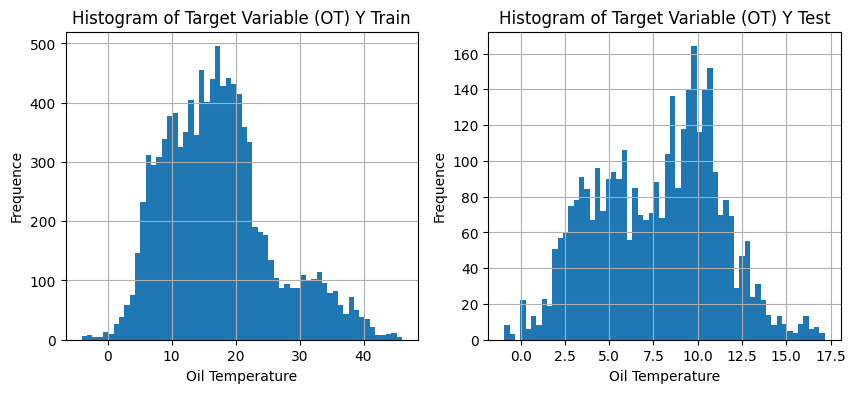

In [69]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist([train_df['OT']],bins = 60)
plt.title('Histogram of Target Variable (OT) Y Train')
plt.xlabel('Oil Temperature')
plt.ylabel('Frequence')
plt.grid(True)
plt.subplot(1,2,2)
plt.hist([test_df['OT']],bins = 60)
plt.title('Histogram of Target Variable (OT) Y Test')
plt.xlabel('Oil Temperature')
plt.ylabel('Frequence')
plt.grid(True)
plt.show()

In [70]:
scaler = StandardScaler()

train_scaled = scaler.fit_transform(train_df.values)
val_scaled   = scaler.transform(val_df.values)
test_scaled  = scaler.transform(test_df.values)

### Inverst Function

In [71]:
def inverst(x,scaler,target_index):
    return x * scaler.scale_[target_index] + scaler.mean_[target_index]

In [72]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_len, pred_len, target_index):
        self.data = data
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.target_index = target_index

    def __len__(self):
        return len(self.data) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_len]
        y = self.data[idx+self.seq_len:idx+self.seq_len+self.pred_len, self.target_index]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

In [73]:

target_index = df.columns.get_loc(target_col)
print(target_index)
train_dataset = TimeSeriesDataset(train_scaled, seq_len, pred_len, target_index)
val_dataset   = TimeSeriesDataset(val_scaled, seq_len, pred_len, target_index)
test_dataset  = TimeSeriesDataset(test_scaled, seq_len, pred_len, target_index)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

4


### Thống kê phân phối dữ liệu sau khi scale

In [74]:
y_train_all = []
y_test_all = []

for i in range(len(train_dataset)):
    _, y = train_dataset[i]
    y_train_all.append(y.numpy())

for i in range(len(test_dataset)):
    _, y = test_dataset[i]
    y_test_all.append(y.numpy())

y_train_all = np.concatenate(y_train_all)
y_test_all = np.concatenate(y_test_all)

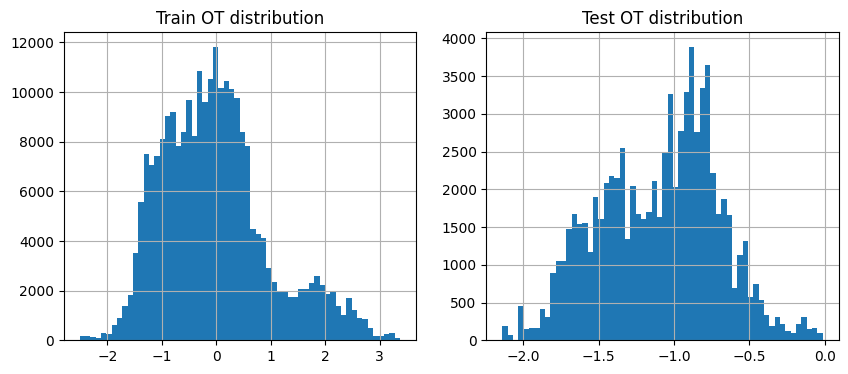

In [75]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(y_train_all, bins=60)
plt.title("Train OT distribution")
plt.grid(True)
plt.subplot(1,2,2)
plt.hist(y_test_all, bins=60)
plt.title("Test OT distribution")
plt.grid(True)
plt.show()

## Seq2SeqLSTM Model

In [76]:
# class Encoder(nn.Module):
#     def __init__(self, input_dim, hidden_size, num_layers, drop_out):
#         super().__init__()
#         self.hidden_size = hidden_size
#         self.num_layers = num_layers

#         self.lstm = nn.LSTM(
#             input_size=input_dim,
#             hidden_size=hidden_size,
#             num_layers=num_layers,
#             dropout=drop_out,
#             batch_first=True,
#             bidirectional=True
#         )

#     def forward(self, x):
#         outputs, (hidden, cell) = self.lstm(x)

#         batch_size = x.size(0)

#         hidden = hidden.view(self.num_layers, 2, batch_size, self.hidden_size)
#         cell = cell.view(self.num_layers, 2, batch_size, self.hidden_size)

#         hidden = torch.cat((hidden[:, 0], hidden[:, 1]), dim=2)
#         cell = torch.cat((cell[:, 0], cell[:, 1]), dim=2)

#         return outputs, hidden, cell
# class Decoder(nn.Module):
#     def __init__(self, hidden_size, num_layers, drop_out):
#         super().__init__()

#         self.lstm = nn.LSTM(
#             input_size=1,
#             hidden_size=hidden_size * 2,
#             num_layers=num_layers,
#             dropout=drop_out,
#             batch_first=True
#         )

#         self.fc = nn.Sequential(
#             nn.Linear(hidden_size * 2, 128),
#             nn.ReLU(),
#             nn.Dropout(drop_out),
#             nn.Linear(128, 1)
#         )

#     def forward(self, decoder_input, hidden, cell):
#         out, (hidden, cell) = self.lstm(decoder_input, (hidden, cell))
#         out = out.squeeze(1)
#         pred = self.fc(out)
#         return pred, hidden, cell

# class Seq2SeqLSTM(nn.Module):
#     def __init__(
#         self,
#         input_dim,
#         hidden_size=128,
#         num_layers=2,
#         pred_len=24,
#         drop_out=0.2,
#         teacher_forcing_ratio=0.2,
#         target_idx=0
#     ):
#         super().__init__()

#         self.encoder = Encoder(input_dim, hidden_size, num_layers, drop_out)
#         self.decoder = Decoder(hidden_size, num_layers, drop_out)

#         self.pred_len = pred_len
#         self.teacher_forcing_ratio = teacher_forcing_ratio
#         self.target_idx = target_idx

#     def forward(self, x, y=None):
#         batch_size = x.size(0)

#         _, hidden, cell = self.encoder(x)

#         decoder_input = x[:, -1:, self.target_idx:self.target_idx+1]

#         outputs = []

#         for t in range(self.pred_len):
#             pred, hidden, cell = self.decoder(decoder_input, hidden, cell)

#             outputs.append(pred.unsqueeze(1))

#             if self.training and y is not None and torch.rand(1).item() < self.teacher_forcing_ratio:
#                 if y.dim() == 2:
#                     decoder_input = y[:, t].unsqueeze(1).unsqueeze(2)
#                 else:
#                     decoder_input = y[:, t:t+1, :]
#             else:
#                 decoder_input = pred.unsqueeze(1)

#         outputs = torch.cat(outputs, dim=1)

#         return outputs.squeeze(-1)

In [77]:
print(train_scaled.shape)

(10452, 10)


In [78]:
# model = Seq2SeqLSTM(
#     input_dim=train_scaled.shape[1],
#     hidden_size=hidden_size,
#     num_layers=num_layer,
#     pred_len=pred_len,
#     drop_out=drop_out,
#     teacher_forcing_ratio=0.2,
#     target_idx=target_idx
# ).to(device)
# criterion = nn.MSELoss()
# optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
# scheduler_reduce = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer,
#     mode = 'min',
#     patience = 3,
#     factor = 0.5
# )


In [79]:
# history = []
# best_val_loss = float('inf')
# train_loss = float('inf')
# best_epoch = 0
# patience = 5
# counter = 0
# for epoch in range(epochs):

#     model.train()
#     total_train_loss = []

#     for X_batch, y_batch in train_loader:
#         X_batch = X_batch.to(device)
#         y_batch = y_batch.to(device)

#         optimizer.zero_grad()

#         output = model(X_batch)
#         loss = criterion(output,y_batch)

#         loss.backward() # Backpropagation Through Time

#         torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Gradien Clipping

#         optimizer.step() # Gradient Descent update
#         y_train_pred = inverst(output.detach().cpu().numpy(),scaler,target_index)
#         y_train_true = inverst(y_batch.detach().cpu().numpy(),scaler,target_index)
#         loss_real = mse_loss(y_train_pred,y_train_true)
#         total_train_loss.append(loss_real)


#     # ===== VALIDATION =====
#     model.eval()
#     total_val_loss = []

#     with torch.no_grad():
#         for X_val_batch,y_val_batch in val_loader:
#             X_val_batch = X_val_batch.to(device)
#             y_val_batch = y_val_batch.to(device)
#             output = model(X_val_batch)
#             y_val_true = inverst(y_val_batch.detach().cpu().numpy(),scaler,target_index)
#             y_val_pred = inverst(output.detach().cpu().numpy(),scaler,target_index)
#             loss = mse_loss(y_val_pred,y_val_true)
#             total_val_loss.append(loss)
#     total_train_loss = np.average(total_train_loss)
#     total_val_loss = np.average(total_val_loss)
#     scheduler_reduce.step(total_val_loss)
#     current_lr = optimizer.param_groups[0]['lr']
#     print(
#         f"Epoch {epoch+1:02d} | "
#         f"Train Loss: {total_train_loss:.4f} | "
#         f"Val Loss: {total_val_loss:.4f} |"
#         f"LR: {current_lr:.6f}"
#     )
#     # ===== SAVE BEST MODEL =====
#     if total_val_loss < best_val_loss:
#         train_loss = total_train_loss
#         best_val_loss = total_val_loss
#         best_epoch = epoch + 1
#         torch.save({
#             'epoch': best_epoch,
#             'model_state_dict': model.state_dict(),
#             'optimizer_state_dict': optimizer.state_dict(),
#             'val_loss': total_val_loss,
#             'train_loss': total_train_loss,
#             'lr':lr,
#             'drop_out':drop_out,
#             'seq_len':seq_len,
#             'pred_len':pred_len
#         }, "seq2seq_checkpoint.pth")
#         counter = 0
#     else:
#         counter += 1
#         if counter >= patience:
#             print("Early stopping")
#             break
#     history.append((total_train_loss,total_val_loss))

In [80]:
# print(f'Best Epoch:{best_epoch}')
# print(f'Train Loss: {train_loss}')
# print(f'Val Loss: {best_val_loss}')

In [81]:
# checkpoint = torch.load("G:\\Code\\Deep Learning\\deeplearning\\seq2seqs_checkpoint.pth", map_location=device)
# model.load_state_dict(checkpoint['model_state_dict'])
# model.eval()
# total_loss=  []
# preds = []
# trues = []

# with torch.no_grad():
#     for x, y in test_loader:
#         x = x.to(device)
#         y = y.to(device)
#         output = model(x)
#         y_val_true = inverst(y.detach().cpu().numpy(),scaler,target_index)
#         y_val_pred = inverst(output.detach().cpu().numpy(),scaler,target_index)
#         loss = mse_loss(y_val_pred,y_val_true)
#         total_loss.append(loss)
#         preds.append(output.cpu().numpy())
#         trues.append(y.cpu().numpy())
#     total_loss = np.average(total_loss)
# print(f'Loss: {total_loss}')
# preds = np.concatenate(preds, axis=0)
# trues = np.concatenate(trues, axis=0)



In [82]:
# print(preds.shape)
# print(trues.shape)

preds_flat = preds.reshape(-1,1)
trues_flat = trues.reshape(-1,1)

dummy_pred = np.zeros((preds_flat.shape[0], train_scaled.shape[1]))
dummy_true = np.zeros((trues_flat.shape[0], train_scaled.shape[1]))

dummy_pred[:, target_index] = preds_flat[:,0]
dummy_true[:, target_index] = trues_flat[:,0]

inv_pred = scaler.inverse_transform(dummy_pred)[:, target_index]
inv_true = scaler.inverse_transform(dummy_true)[:, target_index]

MSE_Real = criterion(torch.tensor(inv_pred),torch.tensor(inv_true))

In [83]:

# # tạo mảng giả để inverse
# dummy_pred = np.zeros((preds.shape[1], train_scaled.shape[1]))
# dummy_true = np.zeros((trues.shape[1], train_scaled.shape[1]))

# dummy_pred[:, target_index] = preds[0]
# dummy_true[:, target_index] = trues[0]

# inv_pred = scaler.inverse_transform(dummy_pred)[:, target_index]
# inv_true = scaler.inverse_transform(dummy_true)[:, target_index]

# MSE_Real = criterion(torch.tensor(inv_pred),torch.tensor(inv_true))

In [84]:
# print(f'Prediction: {inv_pred}')
# print(f'True: {inv_true}')
# print(f'Real Loss: {MSE_Real}')

In [85]:
# plt.figure(figsize=(12,5))
# plt.plot(inv_true[:], label="True")
# plt.plot(inv_pred[:], label="Pred")
# plt.legend()
# plt.show()

## Seq2SeqLSTM + Temporal Attention Model

In [86]:
class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.V = nn.Linear(hidden_dim, 1)

    def forward(self, H, h_t):
        h_t = h_t.unsqueeze(1).repeat(1, H.size(1), 1)

        score = torch.tanh(self.W1(H) + self.W2(h_t))

        # scale (quan trọng)
        score = self.V(score).squeeze(-1) / math.sqrt(H.size(-1))

        weights = torch.softmax(score, dim=1)

        context = torch.sum(weights.unsqueeze(-1) * H, dim=1)

        return context, weights


class LSTM_Attention(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, horizon):
        super().__init__()

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers,
            batch_first=True,
            dropout=drop_out   # regularization
        )

        self.attention = TemporalAttention(hidden_dim)
        # MLP head mạnh hơn
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(drop_out),
            nn.Linear(hidden_dim, horizon)
        )
    def forward(self, x):
        H, (h_n, _) = self.lstm(x)

        h_t = h_n[-1]

        context, weights = self.attention(H, h_t)

        combined = torch.cat([h_t, context], dim=1)

        out = self.fc(combined)

        return out

In [87]:
attention_model = LSTM_Attention(
    input_dim = train_scaled.shape[1],
    hidden_dim = hidden_size,
    num_layers = num_layer,
    horizon = pred_len
).to(device)
atm_criterion = nn.MSELoss()
atm_optimizer = torch.optim.AdamW(attention_model.parameters(), lr=lr)
atm_scheduler_reduce = torch.optim.lr_scheduler.ReduceLROnPlateau(
    atm_optimizer,
    mode = 'min',
    patience = 3,
    factor = 0.5
)
attention_history = []
attention_best_epoch = 0
attention_best_val_loss = float('inf')
attention_train_loss = float('inf')

### Train Fuction + Predict Function

In [88]:
def running_train(model, train_loader, val_loader, optimizer, criterion, scheduler_reduce, device, epochs, history, best_epoch, best_val_loss, train_loss,file):
    patience = 5
    counter = 0
    for epoch in range(epochs):

        model.train()
        total_train_loss = []

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            output = model(X_batch)
            loss = criterion(output,y_batch)

            loss.backward() # Backpropagation Through Time

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # Gradien Clipping

            optimizer.step() # Gradient Descent update
            y_train_pred = inverst(output.detach().cpu().numpy(),scaler,target_index)
            y_train_true = inverst(y_batch.detach().cpu().numpy(),scaler,target_index)
            loss_real = mse_loss(y_train_pred,y_train_true)
            total_train_loss.append(loss_real)


        # ===== VALIDATION =====
        model.eval()
        total_val_loss = []

        with torch.no_grad():
            for X_val_batch,y_val_batch in val_loader:
                X_val_batch = X_val_batch.to(device)
                y_val_batch = y_val_batch.to(device)
                output = attention_model(X_val_batch)
                y_val_true = inverst(y_val_batch.detach().cpu().numpy(),scaler,target_index)
                y_val_pred = inverst(output.detach().cpu().numpy(),scaler,target_index)
                loss = mse_loss(y_val_pred,y_val_true)
                total_val_loss.append(loss)
        total_train_loss = np.average(total_train_loss)
        total_val_loss = np.average(total_val_loss)
        scheduler_reduce.step(total_val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        print(
            f"Epoch {epoch+1:02d} | "
            f"Train Loss: {total_train_loss:.4f} | "
            f"Val Loss: {total_val_loss:.4f} |"
            f"LR: {current_lr:.6f}"
        )
        # ===== SAVE BEST MODEL =====
        if total_val_loss < best_val_loss:
            train_loss = total_train_loss
            best_val_loss = total_val_loss
            best_epoch = epoch + 1
            torch.save({
                'epoch': best_epoch,
                'model_state_dict': attention_model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': total_val_loss,
                'train_loss': total_train_loss,
                'lr':lr,
                'drop_out':drop_out,
                'seq_len':seq_len,
                'pred_len':pred_len
            }, file)
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping")
                break
        history.append((total_train_loss,total_val_loss))
    return best_epoch, best_val_loss, train_loss,history

In [89]:
def predict_running(model,data_loader):
  checkpoint = torch.load("atm_checkpoint.pth", map_location=device, weights_only=False)
  model.load_state_dict(checkpoint['model_state_dict'])
  model.eval()
  total_loss = []
  preds,trues = [],[]
  with torch.no_grad():
      for x, y in test_loader:
          x = x.to(device)
          y = y.to(device)
          output = model(x)
          y_val_true = inverst(y.detach().cpu().numpy(),scaler,target_index)
          y_val_pred = inverst(output.detach().cpu().numpy(),scaler,target_index)
          loss = mse_loss(y_val_pred,y_val_true)
          total_loss.append(loss)
          preds.append(y_val_pred)
          trues.append(y_val_true)
      total_loss = np.average(total_loss)
  print(f'Loss: {total_loss}')
  preds = np.concatenate(preds, axis=0)
  trues = np.concatenate(trues, axis=0)
  print(f'Trues:{trues[0]}')
  print(f'Predict:{preds[0]}')
  return preds,trues,total_loss

### Train LSTM + Attention

In [90]:
attention_best_epoch,attention_best_val_loss,attention_train_loss,attention_history = running_train(
    attention_model,
    train_loader,
    val_loader,
    atm_optimizer,
    atm_criterion,
    atm_scheduler_reduce,
    device,
    epochs,
    attention_history,
    attention_best_epoch,
    attention_best_val_loss,
    attention_train_loss,
    'atm_checkpoint.pth'
)

Epoch 01 | Train Loss: 27.2749 | Val Loss: 12.3019 |LR: 0.000100
Epoch 02 | Train Loss: 8.6556 | Val Loss: 8.4377 |LR: 0.000100
Epoch 03 | Train Loss: 7.3600 | Val Loss: 3.7682 |LR: 0.000100
Epoch 04 | Train Loss: 6.4238 | Val Loss: 4.5386 |LR: 0.000100
Epoch 05 | Train Loss: 5.5813 | Val Loss: 3.9709 |LR: 0.000100
Epoch 06 | Train Loss: 4.9724 | Val Loss: 2.9769 |LR: 0.000100
Epoch 07 | Train Loss: 4.6351 | Val Loss: 3.2046 |LR: 0.000100
Epoch 08 | Train Loss: 4.3998 | Val Loss: 2.6757 |LR: 0.000100
Epoch 09 | Train Loss: 4.1716 | Val Loss: 2.8485 |LR: 0.000100
Epoch 10 | Train Loss: 3.9712 | Val Loss: 2.0084 |LR: 0.000100
Epoch 11 | Train Loss: 3.8717 | Val Loss: 1.8468 |LR: 0.000100
Epoch 12 | Train Loss: 3.7475 | Val Loss: 2.1199 |LR: 0.000100
Epoch 13 | Train Loss: 3.6365 | Val Loss: 2.2041 |LR: 0.000100
Epoch 14 | Train Loss: 3.6337 | Val Loss: 2.8462 |LR: 0.000100
Epoch 15 | Train Loss: 3.4819 | Val Loss: 1.8095 |LR: 0.000100
Epoch 16 | Train Loss: 3.4885 | Val Loss: 2.6817 |LR:

In [91]:
print(f'Best Epoch:{attention_best_epoch}')
print(f'Train Loss: {attention_train_loss}')
print(f'Val Loss: {attention_best_val_loss}')

Best Epoch:15
Train Loss: 3.481928908063863
Val Loss: 1.8094939473363174


### Predict LSTM + Attention Model

In [92]:
atm_preds,atm_trues,atm_total_loss = predict_running(attention_model,test_loader)

Loss: 1.648564440553276
Trues:[3.44699973 3.86900046 3.37700052 2.81399965 2.74400044 2.88399988
 2.81399965 2.6030003  2.81399965 2.6030003  2.95499979 2.88399988
 3.37700052 3.30599959 3.30599959 3.30599959 3.37700052 3.58799987
 3.72800033 4.64299967 5.69799947 5.48700012 5.7679997  5.7679997 ]
Predict:[3.93490148 3.89289343 3.74580688 3.63573606 3.617555   3.53186938
 3.41956982 3.2431159  3.22988962 3.2059175  3.44086055 3.21803651
 3.59161802 3.73249434 3.80594424 4.36582122 4.65308177 5.27399328
 5.2898979  5.74585441 5.99333056 6.1628892  6.22213952 6.00597429]


### Plot Predict

In [93]:
def plot_function (preds,trues,total_loss,idx,criterion):
  MSE_Loss = criterion(torch.tensor(preds[idx]),torch.tensor(trues[idx]))
  print(f'Total Loss: {total_loss}')
  print(f'Sample {idx} Loss: {MSE_Loss}')
  plt.figure(figsize=(12,5))
  plt.plot(trues[idx], label="True")
  plt.plot(preds[idx], label="Pred")
  plt.title('Predict Plot')
  plt.legend()
  plt.show()

Total Loss: 1.648564440553276
Sample 5 Loss: 0.9651812280539355


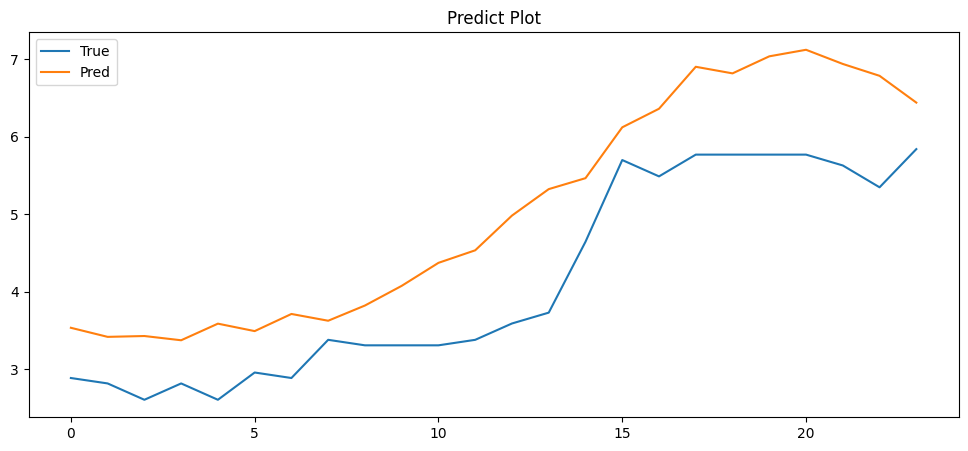

In [94]:
plot_function(atm_preds,atm_trues,atm_total_loss,5,atm_criterion)